In [21]:
# =========================
# BLOCK 1 — IMPORT LIBS
# =========================

import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred

fred = Fred(api_key='986a305fb9609a42130a8cf18bd7ca94')

## Importing

### function

In [22]:
# =====================================================
# BLOCK DIAGNOSTICS (DISPLAY + DICT KEY OR OBJ.NAME)
# =====================================================

from IPython.display import display

def block_diagnostics(series_list, block_name, source_dict=None):
    
    display(f"=== {block_name} DIAGNOSTICS ===")
    
    summary = []
    
    for i, s in enumerate(series_list):
        
        var_name = None
        
        # 1) Prefer dict key if provided
        if source_dict is not None:
            for key, val in source_dict.items():
                if val is s:
                    var_name = key
                    break
        
        # 2) Else use object name
        if var_name is None:
            var_name = s.name if getattr(s, "name", None) else None
        
        # 3) Fallback
        if var_name is None:
            var_name = f"Series_{i+1}"
        
        time_diffs = s.index.to_series().diff().dropna()
        most_common_gap = (
            time_diffs.dt.days.mode()[0]
            if not time_diffs.empty
            else None
        )
        
        summary.append({
            "variable": var_name,
            "start": s.index.min(),
            "end": s.index.max(),
            "n_obs": len(s),
            "n_nan": s.isna().sum(),
            "most_common_gap": most_common_gap
        })
    
    display(pd.DataFrame(summary))


### YFINANCE

In [23]:
# ==================================
# BLOCK 2 — LOAD YFINANCE
# ==================================

yf_raw = {}

In [24]:
# =====================================================
# SP500
# =====================================================

print("\nDownloading SP500 (^GSPC)...")

sp_df = yf.download(
    "^GSPC",
    period="max",
    interval="1d",
    auto_adjust=True,
    progress=False
)

if sp_df.empty:
    raise ValueError("Download failed for SP500")

if isinstance(sp_df.columns, pd.MultiIndex):
    sp_df.columns = sp_df.columns.get_level_values(0)

if "Close" not in sp_df.columns:
    raise ValueError("'Close' column not found for SP500")

sp500 = sp_df["Close"].copy().rename("SP500")
yf_raw[sp500.name] = sp500

print(f"✔ SP500 loaded | Obs: {len(sp500)}")


✔ SP500 loaded | Obs: 24676


In [25]:
block_diagnostics(
    [sp500],
    "YFINANCE — SP500"
)

'=== YFINANCE — SP500 DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,SP500,1927-12-30,2026-03-27,24676,0,1


In [26]:
# =====================================================
# VOLATILITY
# =====================================================

print("\nDownloading VIX (^VIX)...")

vix_df = yf.download(
    "^VIX",
    period="max",
    interval="1d",
    auto_adjust=True,
    progress=False
)

if vix_df.empty:
    raise ValueError("Download failed for VIX")

if isinstance(vix_df.columns, pd.MultiIndex):
    vix_df.columns = vix_df.columns.get_level_values(0)

if "Close" not in vix_df.columns:
    raise ValueError("'Close' column not found for VIX")

vix = vix_df["Close"].copy().rename("VIX")
yf_raw[vix.name] = vix

print(f"✔ VIX loaded | Obs: {len(vix)}")


# =====================================================
# DERIVED VARIABLES
# =====================================================

# --- Implied Volatility (VIX) ---

vix = yf_raw["VIX"]

# Implied variance (annualized)
iv_var = ((vix / 100) ** 2).rename("IV_VAR")


# --- Realized Volatility (from SP500) ---

sp = yf_raw["SP500"]

# Log returns
sp_log_ret = np.log(sp).diff().rename("SP500_Log_Return")

# 30-day rolling realized volatility (annualized)
rv_30d = (sp_log_ret.rolling(30).std() * np.sqrt(252)).rename("RV_30D")

# Realized variance
rv_var = (rv_30d ** 2).rename("RV_30D_VAR")


# --- Variance Risk Premium (VRP) ---

vrp = (iv_var - rv_var).rename("VRP")


# Store derived volatility variables
for s in [
    #sp_log_ret,
    rv_30d,
    iv_var,
    rv_var,
    vrp
]:
    yf_raw[s.name] = s



✔ VIX loaded | Obs: 9126


In [27]:
block_diagnostics(
    [vix, rv_30d, iv_var, rv_var, vrp],
    "YFINANCE — VOLATILITY"
)


'=== YFINANCE — VOLATILITY DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,VIX,1990-01-02,2026-03-27,9126,0,1
1,RV_30D,1927-12-30,2026-03-27,24676,30,1
2,IV_VAR,1990-01-02,2026-03-27,9126,0,1
3,RV_30D_VAR,1927-12-30,2026-03-27,24676,30,1
4,VRP,1927-12-30,2026-03-27,24676,15550,1


In [28]:
# =====================================================
# SECTOR ROTATION — ETFS
# =====================================================

sector_tickers = [
    #"SPY",
    "XLK", "XLY", "XLI", "XLF", "XLB", "XLE", "XLC",  # Cyclicals
    "XLP", "XLU", "XLV", "XLRE"                      # Defensives
]

print("\nDownloading Sector Rotation ETFs...")

for ticker in sector_tickers:
    
    df = yf.download(
        ticker,
        period="max",
        interval="1d",
        auto_adjust=True,
        progress=False
    )
    
    if df.empty:
        raise ValueError(f"Download failed for {ticker}")
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    if "Close" not in df.columns:
        raise ValueError(f"'Close' column not found for {ticker}")
    
    series = df["Close"].copy().rename(ticker)
    yf_raw[series.name] = series
    
    print(f"✔ {ticker} loaded | Obs: {len(series)}")
    
# =====================================================
# DERIVED VARIABLES
# =====================================================

CYCLICALS = ["XLK", "XLY", "XLI", "XLF", "XLB", "XLE", "XLC"]
DEFENSIVES = ["XLP", "XLU", "XLV", "XLRE"]

# Combine ETF prices from yf_raw
etf_prices = pd.concat(
    [yf_raw[t] for t in CYCLICALS + DEFENSIVES],
    axis=1
)

# Daily log returns
rets = np.log(etf_prices / etf_prices.shift(1)).dropna()

# Equal-weight baskets
cyc_ret = rets[CYCLICALS].mean(axis=1)
def_ret = rets[DEFENSIVES].mean(axis=1)

# Cyclical minus Defensive differential
sector_rotation = (cyc_ret - def_ret).rename("Sector_Rotation")

# Store
# yf_raw[sector_rotation.name] = sector_rotation



✔ XLK loaded | Obs: 6857
✔ XLY loaded | Obs: 6857
✔ XLI loaded | Obs: 6857
✔ XLF loaded | Obs: 6857
✔ XLB loaded | Obs: 6857
✔ XLE loaded | Obs: 6857
✔ XLC loaded | Obs: 1954
✔ XLP loaded | Obs: 6857
✔ XLU loaded | Obs: 6857
✔ XLV loaded | Obs: 6857
✔ XLRE loaded | Obs: 2632


In [29]:
block_diagnostics(
    [yf_raw["XLK"], yf_raw["XLY"], yf_raw["XLI"], yf_raw["XLF"],
     yf_raw["XLB"], yf_raw["XLE"], yf_raw["XLC"],
     yf_raw["XLP"], yf_raw["XLU"], yf_raw["XLV"], yf_raw["XLRE"],
     sector_rotation],
    "YFINANCE — SECTOR ROTATION",
    source_dict=yf_raw
)

'=== YFINANCE — SECTOR ROTATION DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,XLK,1998-12-22,2026-03-27,6857,0,1
1,XLY,1998-12-22,2026-03-27,6857,0,1
2,XLI,1998-12-22,2026-03-27,6857,0,1
3,XLF,1998-12-22,2026-03-27,6857,0,1
4,XLB,1998-12-22,2026-03-27,6857,0,1
5,XLE,1998-12-22,2026-03-27,6857,0,1
6,XLC,2018-06-19,2026-03-27,1954,0,1
7,XLP,1998-12-22,2026-03-27,6857,0,1
8,XLU,1998-12-22,2026-03-27,6857,0,1
9,XLV,1998-12-22,2026-03-27,6857,0,1


In [30]:
# =====================================================
# OTHER ASSETS
# =====================================================

other_asset_tickers = {
    "WTI_Crude_Oil": "CL=F",
    "Natural_Gas": "NG=F",
    "Copper": "HG=F",
    "Gold": "GC=F",
    "Silver": "SI=F",
    "Bitcoin": "BTC-USD",
    "Bloomberg_Commodity_Index_ETF": "DBC",
}

print("\nDownloading Other Assets...")

for name, ticker in other_asset_tickers.items():
    
    df = yf.download(
        ticker,
        period="max",
        interval="1d",
        auto_adjust=True,
        progress=False
    )
    
    if df.empty:
        raise ValueError(f"Download failed for {ticker}")
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    if "Close" not in df.columns:
        raise ValueError(f"'Close' column not found for {ticker}")
    
    series = df["Close"].copy().rename(name)
    
    yf_raw[series.name] = series
    
    print(f"✔ {name} loaded | Obs: {len(series)}")


✔ WTI_Crude_Oil loaded | Obs: 6426
✔ Natural_Gas loaded | Obs: 6423
✔ Copper loaded | Obs: 6422
✔ Gold loaded | Obs: 6417
✔ Silver loaded | Obs: 6419
✔ Bitcoin loaded | Obs: 4212
✔ Bloomberg_Commodity_Index_ETF loaded | Obs: 5067


In [31]:
block_diagnostics(
    [yf_raw["WTI_Crude_Oil"],
     yf_raw["Natural_Gas"],
     yf_raw["Copper"],
     yf_raw["Gold"],
     yf_raw["Silver"],
     yf_raw["Bitcoin"],
     yf_raw["Bloomberg_Commodity_Index_ETF"]],
    "YFINANCE — OTHER ASSETS",
    source_dict=yf_raw
)

'=== YFINANCE — OTHER ASSETS DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,WTI_Crude_Oil,2000-08-23,2026-03-27,6426,0,1
1,Natural_Gas,2000-08-30,2026-03-27,6423,0,1
2,Copper,2000-08-30,2026-03-27,6422,0,1
3,Gold,2000-08-30,2026-03-27,6417,0,1
4,Silver,2000-08-30,2026-03-27,6419,0,1
5,Bitcoin,2014-09-17,2026-03-29,4212,0,1
6,Bloomberg_Commodity_Index_ETF,2006-02-06,2026-03-27,5067,0,1


In [32]:
# =========================
# SUMMARY — LOADED VARIABLES
# =========================

print("\n✔ YFIN VARIABLES LOADED SUCCESSFULLY")
print(f"Total variables loaded: {len(yf_raw)}\n")

for name in sorted(yf_raw.keys()):
    series = yf_raw[name]
    print(f"{name:35} | Obs: {len(series):6} | Start: {series.index.min().date()} | End: {series.index.max().date()}")




✔ YFIN VARIABLES LOADED SUCCESSFULLY
Total variables loaded: 24

Bitcoin                             | Obs:   4212 | Start: 2014-09-17 | End: 2026-03-29
Bloomberg_Commodity_Index_ETF       | Obs:   5067 | Start: 2006-02-06 | End: 2026-03-27
Copper                              | Obs:   6422 | Start: 2000-08-30 | End: 2026-03-27
Gold                                | Obs:   6417 | Start: 2000-08-30 | End: 2026-03-27
IV_VAR                              | Obs:   9126 | Start: 1990-01-02 | End: 2026-03-27
Natural_Gas                         | Obs:   6423 | Start: 2000-08-30 | End: 2026-03-27
RV_30D                              | Obs:  24676 | Start: 1927-12-30 | End: 2026-03-27
RV_30D_VAR                          | Obs:  24676 | Start: 1927-12-30 | End: 2026-03-27
SP500                               | Obs:  24676 | Start: 1927-12-30 | End: 2026-03-27
Silver                              | Obs:   6419 | Start: 2000-08-30 | End: 2026-03-27
VIX                                 | Obs:   9126 | St

### FREDAPI

In [33]:
# =========================
# BLOCK 3 — LOAD FRED DATA
# =========================

fred_raw = {}

In [34]:
# =====================================================
# FX
# =====================================================

dxy_broad = fred.get_series('DTWEXBGS').rename('USD_Broad_Index')
usd_jpy = fred.get_series('DEXJPUS').rename('USD_JPY')
usd_chf = fred.get_series('DEXSZUS').rename('USD_CHF')

jp_policy_rate = fred.get_series('IRSTCI01JPM156N').rename('Japan_Policy_Rate')
jp_10y = fred.get_series('IRLTLT01JPM156N').rename('Japan_10Y_JGB')

# Store FX
for s in [dxy_broad, usd_jpy, usd_chf, jp_policy_rate, jp_10y]:
    fred_raw[s.name] = s

In [35]:
block_diagnostics(
    [dxy_broad, usd_jpy, usd_chf,
     jp_policy_rate, jp_10y],
    "FRED — FX"
)

'=== FRED — FX DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,USD_Broad_Index,2006-01-02,2026-03-20,5275,208,1
1,USD_JPY,1971-01-04,2026-03-20,14405,566,1
2,USD_CHF,1971-01-04,2026-03-20,14405,560,1
3,Japan_Policy_Rate,1985-07-01,2026-02-01,488,0,31
4,Japan_10Y_JGB,1989-01-01,2026-02-01,446,0,31


In [36]:
# =====================================================
# REAL ACTIVITY
# =====================================================

industrial_production = fred.get_series('INDPRO').rename('Industrial_Production')
unemployment_rate = fred.get_series('UNRATE').rename('Unemployment_Rate')
buffett_indicator = fred.get_series('DDDM01USA156NWDB').rename('MarketCap_to_GDP')
consumer_sentiment = fred.get_series('UMCSENT').rename('Consumer_Sentiment')
building_permits = fred.get_series('PERMIT').rename('Building_Permits')
retail_sales = fred.get_series('RSAFS').rename('Retail_Sales')

for s in [
    industrial_production,
    unemployment_rate,
    buffett_indicator,
    consumer_sentiment,
    building_permits,
    retail_sales
]:
    fred_raw[s.name] = s

In [37]:
block_diagnostics(
    [industrial_production,
     unemployment_rate,
     buffett_indicator,
     consumer_sentiment,
     building_permits,
     retail_sales],
    "FRED — REAL ACTIVITY"
)


'=== FRED — REAL ACTIVITY DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,Industrial_Production,1919-01-01,2026-02-01,1286,0,31
1,Unemployment_Rate,1948-01-01,2026-02-01,938,1,31
2,MarketCap_to_GDP,1975-01-01,2020-01-01,46,0,365
3,Consumer_Sentiment,1952-11-01,2026-02-01,880,210,31
4,Building_Permits,1960-01-01,2026-01-01,793,0,31
5,Retail_Sales,1992-01-01,2026-01-01,409,0,31


In [38]:
# =====================================================
# CREDIT STRESS AND FINANCIAL CONDITIONS
# =====================================================

# --- RAW SERIES (from FRED) ---

aaa_yield = fred.get_series("AAA").dropna()
aaa_yield.name = "AAA_Yield"

bbb_yield = fred.get_series("BAA").dropna()
bbb_yield.name = "BBB_Yield"

hy_yield = fred.get_series("BAMLH0A0HYM2").dropna()
hy_yield.name = "HY_Yield"

us_10y = fred.get_series("GS10").dropna()
us_10y.name = "US10Y_Yield"

ig_spread = fred.get_series("BAMLC0A0CM").dropna()
ig_spread.name = "IG_OAS_Spread"

cp_3m = fred.get_series("DCPN3M").dropna()
cp_3m.name = "CP_3M"

tbill_3m = fred.get_series("DTB3").dropna()
tbill_3m.name = "TBILL_3M"

nfci = fred.get_series("NFCI").dropna()
nfci.name = "NFCI"


# =====================================================
# DERIVED VARIABLES
# =====================================================

# --- Credit Quality Dispersion (BBB − AAA) ---
BBB_AAA_credit_spread = (bbb_yield - aaa_yield).dropna().rename("BBB_AAA_Credit_Spread")

# --- High Yield Spread (HY − Treasury) ---
high_yield_spread = (hy_yield - us_10y).dropna().rename("High_Yield_Spread")

# --- Short-Term Funding Stress (CP − TBill) ---
st_credit_spread = (cp_3m - tbill_3m).dropna().rename("Short_Term_Credit_Spread")

# --- Long-Term Credit Spread (BBB − Treasury) ---
lt_credit_spread = (bbb_yield - us_10y).dropna().rename("Long_Term_Credit_Spread")

# --- Term Structure of Credit Risk ---
c_s_term_struct = (st_credit_spread - lt_credit_spread).dropna().rename("Credit_Spread_Term_Struct")


# =====================================================
# STORE RAW FRED VARIABLES ONLY
# =====================================================

for s in [
    aaa_yield,
    bbb_yield,
    hy_yield,
    us_10y,
    ig_spread,
    cp_3m,
    tbill_3m,
    nfci
]:
    fred_raw[s.name] = s

In [39]:
block_diagnostics(
    [aaa_yield,
     bbb_yield,
     hy_yield,
     us_10y,
     cp_3m,
     tbill_3m,
     BBB_AAA_credit_spread,
     high_yield_spread,
     ig_spread,
     st_credit_spread,
     lt_credit_spread,
     c_s_term_struct,
     nfci],
    "FRED — CREDIT STRESS & FINANCIAL CONDITIONS (ALL VARIABLES)"
)


'=== FRED — CREDIT STRESS & FINANCIAL CONDITIONS (ALL VARIABLES) DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,AAA_Yield,1919-01-01,2026-02-01,1286,0,31
1,BBB_Yield,1919-01-01,2026-02-01,1286,0,31
2,HY_Yield,1996-12-31,2026-03-26,7634,0,1
3,US10Y_Yield,1953-04-01,2026-02-01,875,0,31
4,CP_3M,1997-01-02,2026-03-26,5257,0,1
5,TBILL_3M,1954-01-04,2026-03-26,18048,0,1
6,BBB_AAA_Credit_Spread,1919-01-01,2026-02-01,1286,0,31
7,High_Yield_Spread,1997-04-01,2025-12-01,226,0,31
8,IG_OAS_Spread,1996-12-31,2026-03-26,7633,0,1
9,Short_Term_Credit_Spread,1997-01-02,2026-03-26,5254,0,1


In [40]:
# =====================================================
# INFLATION
# =====================================================

# CPI (headline)
cpi = fred.get_series('CPIAUCNS').rename('CPI')

# Core CPI
core_cpi = fred.get_series('CPILFESL').rename('Core_CPI')

# YoY inflation
cpi_yoy = (cpi.pct_change(12, fill_method=None) * 100).rename('CPI_YoY')
core_cpi_yoy = (core_cpi.pct_change(12, fill_method=None) * 100).rename('Core_CPI_YoY')

# Core − Headline inflation spread
core_minus_cpi = (core_cpi_yoy - cpi_yoy).rename('Core_minus_Headline_Inflation')

# Market-based expected inflation
expected_inflation_5y = fred.get_series('T5YIE').rename('Expected_Inflation_5Y')
expected_inflation_10y = fred.get_series('T10YIE').rename('Expected_Inflation_10Y')

for s in [
    cpi,
    core_cpi,
    cpi_yoy,
    core_cpi_yoy,
    core_minus_cpi,
    expected_inflation_5y,
    expected_inflation_10y
]:
    fred_raw[s.name] = s

In [41]:
block_diagnostics(
    [cpi,
     core_cpi,
     cpi_yoy,
     core_cpi_yoy,
     core_minus_cpi,
     expected_inflation_5y,
     expected_inflation_10y],
    "FRED — INFLATION (ALL VARIABLES)"
)

'=== FRED — INFLATION (ALL VARIABLES) DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,CPI,1913-01-01,2026-02-01,1358,1,31
1,Core_CPI,1957-01-01,2026-02-01,830,1,31
2,CPI_YoY,1913-01-01,2026-02-01,1358,13,31
3,Core_CPI_YoY,1957-01-01,2026-02-01,830,13,31
4,Core_minus_Headline_Inflation,1913-01-01,2026-02-01,1358,541,31
5,Expected_Inflation_5Y,2003-01-02,2026-03-27,6062,250,1
6,Expected_Inflation_10Y,2003-01-02,2026-03-27,6062,250,1


In [42]:
# =====================================================
# LIQUIDITY
# =====================================================

# --- RAW SERIES (from FRED) ---

walcl = fred.get_series("WALCL").dropna()
walcl.name = "Fed_Total_Assets"

tga = fred.get_series("WTREGEN").dropna()
tga.name = "Treasury_General_Account"

rrp = fred.get_series("RRPONTSYD").dropna()
rrp.name = "Reverse_Repo"

reserves = fred.get_series("WRESBAL").dropna()
reserves.name = "Bank_Reserves"


# =====================================================
# DERIVED VARIABLES
# =====================================================

# Net Liquidity (NLQ = Fed Assets − TGA − RRP)
net_liquidity = (walcl - tga - rrp).dropna().rename("Net_Liquidity")


# =====================================================
# STORE RAW FRED VARIABLES ONLY
# =====================================================

for s in [
    walcl,
    tga,
    rrp,
    reserves
]:
    fred_raw[s.name] = s


In [43]:
block_diagnostics(
    [walcl,
     tga,
     rrp,
     reserves,
     net_liquidity],
    "FRED — LIQUIDITY (ALL VARIABLES)"
)

'=== FRED — LIQUIDITY (ALL VARIABLES) DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,Fed_Total_Assets,2002-12-18,2026-03-25,1215,0,7
1,Treasury_General_Account,2002-12-18,2026-03-25,1215,0,7
2,Reverse_Repo,2003-02-07,2026-03-27,3209,0,1
3,Bank_Reserves,2002-12-18,2026-03-25,1215,0,7
4,Net_Liquidity,2003-03-19,2026-03-25,666,0,7


In [44]:
# =====================================================
# INTEREST RATES & YIELD CURVE
# =====================================================

# Nominal Treasury Yields
us_10y = fred.get_series('DGS10').rename('US_10Y_Treasury')
us_2y = fred.get_series('DGS2').rename('US_2Y_Treasury')
us_3m = fred.get_series('DGS3MO').rename('US_3M_Treasury')

# Real 10Y Treasury Yield (TIPS)
real_10y = fred.get_series('DFII10').rename('US_10Y_Real_Yield')

# =====================================================
# DERIVED VARIABLES
# =====================================================

# Yield Curve Spreads
spread_10y_2y = (us_10y - us_2y).rename('Spread_10Y_2Y')
spread_10y_3m = (us_10y - us_3m).rename('Spread_10Y_3M')


# Store interest rate variables
for s in [
    us_10y,
    us_2y,
    us_3m,
    real_10y,
    #spread_10y_2y,
    #spread_10y_3m
]:
    fred_raw[s.name] = s


In [45]:
block_diagnostics(
    [us_10y,
     us_2y,
     us_3m,
     real_10y,
     spread_10y_2y,
     spread_10y_3m],
    "FRED — INTEREST RATES & YIELD CURVE (ALL VARIABLES)"
)

'=== FRED — INTEREST RATES & YIELD CURVE (ALL VARIABLES) DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,US_10Y_Treasury,1962-01-02,2026-03-26,16758,716,1
1,US_2Y_Treasury,1976-06-01,2026-03-26,12998,548,1
2,US_3M_Treasury,1981-09-01,2026-03-26,11628,488,1
3,US_10Y_Real_Yield,2003-01-02,2026-03-26,6061,250,1
4,Spread_10Y_2Y,1962-01-02,2026-03-26,16758,4308,1
5,Spread_10Y_3M,1962-01-02,2026-03-26,16758,5618,1


In [46]:
# =====================================================
# VALUATION FACTORS
# =====================================================

# --- Corporate Profits After Tax (Quarterly Level) ---

profits = fred.get_series('CPATAX').rename('Corporate_Profits_After_Tax')


# --- Corporate Profits YoY Growth (%) ---
# Quarterly → YoY using 4-quarter change

profits_yoy = (
    profits.pct_change(4) * 100
).dropna().rename('Corporate_Profits_YoY')


# --- Corporate Profits as % of GDP ---

profits_gdp = fred.get_series('A053RC1Q027SBEA') \
    .rename('Corporate_Profits_pct_GDP')


# Store variables
for s in [
    profits,
    profits_yoy,
    profits_gdp
]:
    fred_raw[s.name] = s

In [47]:
block_diagnostics(
    [profits,
     profits_yoy,
     profits_gdp],
    "FRED — VALUATION FACTORS"
)

'=== FRED — VALUATION FACTORS DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,Corporate_Profits_After_Tax,1946-01-01,2025-07-01,319,4,92
1,Corporate_Profits_YoY,1948-01-01,2025-07-01,311,0,92
2,Corporate_Profits_pct_GDP,1947-01-01,2025-07-01,315,0,92


In [48]:
# =========================
# SUMMARY — LOADED FRED VARIABLES
# =========================

print("\n✔ FRED VARIABLES LOADED SUCCESSFULLY")
print(f"Total variables loaded: {len(fred_raw)}\n")

for name in sorted(fred_raw.keys()):
    series = fred_raw[name]
    print(f"{name:35} | Obs: {len(series):6} | Start: {series.index.min().date()} | End: {series.index.max().date()}")




✔ FRED VARIABLES LOADED SUCCESSFULLY
Total variables loaded: 37

AAA_Yield                           | Obs:   1286 | Start: 1919-01-01 | End: 2026-02-01
BBB_Yield                           | Obs:   1286 | Start: 1919-01-01 | End: 2026-02-01
Bank_Reserves                       | Obs:   1215 | Start: 2002-12-18 | End: 2026-03-25
Building_Permits                    | Obs:    793 | Start: 1960-01-01 | End: 2026-01-01
CPI                                 | Obs:   1358 | Start: 1913-01-01 | End: 2026-02-01
CPI_YoY                             | Obs:   1358 | Start: 1913-01-01 | End: 2026-02-01
CP_3M                               | Obs:   5257 | Start: 1997-01-02 | End: 2026-03-26
Consumer_Sentiment                  | Obs:    880 | Start: 1952-11-01 | End: 2026-02-01
Core_CPI                            | Obs:    830 | Start: 1957-01-01 | End: 2026-02-01
Core_CPI_YoY                        | Obs:    830 | Start: 1957-01-01 | End: 2026-02-01
Core_minus_Headline_Inflation       | Obs:   1358 | St

### Google Trends

In [49]:
import os
import re

google_trends_path = "google_trends"

google_trends_data = {}
google_trends_series = {}

for file in os.listdir(google_trends_path):
    if file.endswith(".csv"):
        
        base_name = file.replace(".csv", "")
        base_name = re.sub(r'\s+[a-zA-Z]{3}\d{1,2}_\d{4}$', '', base_name)
        var_name = base_name.replace(" ", "_")
        
        df = pd.read_csv(
            os.path.join(google_trends_path, file),
            skiprows=3,
            names=['Month', var_name],
            parse_dates=['Month'],
            index_col='Month'
        )
        
        df[var_name] = pd.to_numeric(df[var_name], errors='coerce')
        df = df.resample('ME').mean()
        df = df.iloc[:-1]
        
        # Store DataFrame
        google_trends_data[var_name] = df
        
        # Store Series
        series = df[var_name].dropna()
        google_trends_series[var_name] = series
        
        # Optional: create both as variables
        globals()[var_name] = df
        globals()[f"{var_name}_s"] = series

print("Loaded DataFrames:", list(google_trends_data.keys()))
print("Loaded Series:", list(google_trends_series.keys()))

Loaded DataFrames: ['credit_card_debt', 'foodbanks_near_me', 'help_with_mortgage', 'resume_template', 'sell_jewelry']
Loaded Series: ['credit_card_debt', 'foodbanks_near_me', 'help_with_mortgage', 'resume_template', 'sell_jewelry']


In [50]:
# =====================================================
# STORE GOOGLE TRENDS VARIABLES
# =====================================================

trends_raw = {}

for key, s in google_trends_series.items():
    trends_raw[key] = s

In [51]:
block_diagnostics(
    list(trends_raw.values()),
    "GOOGLE TRENDS"
)

'=== GOOGLE TRENDS DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,credit_card_debt,2004-03-31,2026-01-31,263,0,31
1,foodbanks_near_me,2004-03-31,2026-01-31,263,0,31
2,help_with_mortgage,2004-03-31,2026-01-31,263,0,31
3,resume_template,2004-03-31,2026-01-31,263,0,31
4,sell_jewelry,2004-03-31,2026-01-31,263,0,31


In [52]:
# =========================
# SUMMARY — LOADED VARIABLES
# =========================

print("\n✔ GOOGLE TRENDS VARIABLES LOADED SUCCESSFULLY")
print(f"Total variables loaded: {len(trends_raw)}\n")

for name in sorted(trends_raw.keys()):
    series = trends_raw[name]
    print(f"{name:35} | Obs: {len(series):6} | Start: {series.index.min().date()} | End: {series.index.max().date()}")



✔ GOOGLE TRENDS VARIABLES LOADED SUCCESSFULLY
Total variables loaded: 5

credit_card_debt                    | Obs:    263 | Start: 2004-03-31 | End: 2026-01-31
foodbanks_near_me                   | Obs:    263 | Start: 2004-03-31 | End: 2026-01-31
help_with_mortgage                  | Obs:    263 | Start: 2004-03-31 | End: 2026-01-31
resume_template                     | Obs:    263 | Start: 2004-03-31 | End: 2026-01-31
sell_jewelry                        | Obs:    263 | Start: 2004-03-31 | End: 2026-01-31


### URL

In [53]:
print("\nDownloading Shiller CAPE (Yale)...")

url = "http://www.econ.yale.edu/~shiller/data/ie_data.xls"

shiller_df = pd.read_excel(
    url,
    sheet_name="Data",
    skiprows=7
)

# Rename first column to Date
shiller_df = shiller_df.rename(columns={shiller_df.columns[0]: "Date"})
shiller_df = shiller_df[shiller_df["Date"].notna()].copy()

# --- Parse Shiller fractional date format ---

def parse_shiller_date(x):
    y = int(np.floor(x))
    m = int(round((x - y) * 100))
    m = min(max(m, 1), 12)
    return pd.Timestamp(year=y, month=m, day=1) + pd.offsets.MonthEnd(0)

shiller_df["Date"] = shiller_df["Date"].apply(parse_shiller_date)
shiller_df = shiller_df.set_index("Date")

# --- Find CAPE column ---

cape_col = None

for c in shiller_df.columns:
    if str(c).strip().upper() == "CAPE":
        cape_col = c
        break

if cape_col is None:
    for c in shiller_df.columns:
        if "P/E" in str(c).upper() and "10" in str(c):
            cape_col = c
            break

if cape_col is None:
    raise ValueError("CAPE column not found in Shiller dataset.")

# --- Extract CAPE ---

shiller_cape = (
    shiller_df[cape_col]
    .astype(float)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .rename("SHILLER_CAPE")
)

print(f"✔ Shiller CAPE loaded | Obs: {len(shiller_cape)}")


✔ Shiller CAPE loaded | Obs: 1713


In [54]:
# --- CAPE Earnings Yield (1 / CAPE) ---

cape_ey_pct = (
    (100 * (1.0 / shiller_cape))
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .rename("CAPE_EY_PCT")
)

In [55]:
url_raw = {}

for s in [
    shiller_cape,
    cape_ey_pct
]:
    url_raw[s.name] = s

In [56]:
block_diagnostics(
    [shiller_cape, cape_ey_pct],
    "URL — SHILLER"
)

'=== URL — SHILLER DIAGNOSTICS ==='

,variable,start,end,n_obs,n_nan,most_common_gap
0,SHILLER_CAPE,1881-01-31,2023-09-30,1713,0,31
1,CAPE_EY_PCT,1881-01-31,2023-09-30,1713,0,31


### GRAPHS

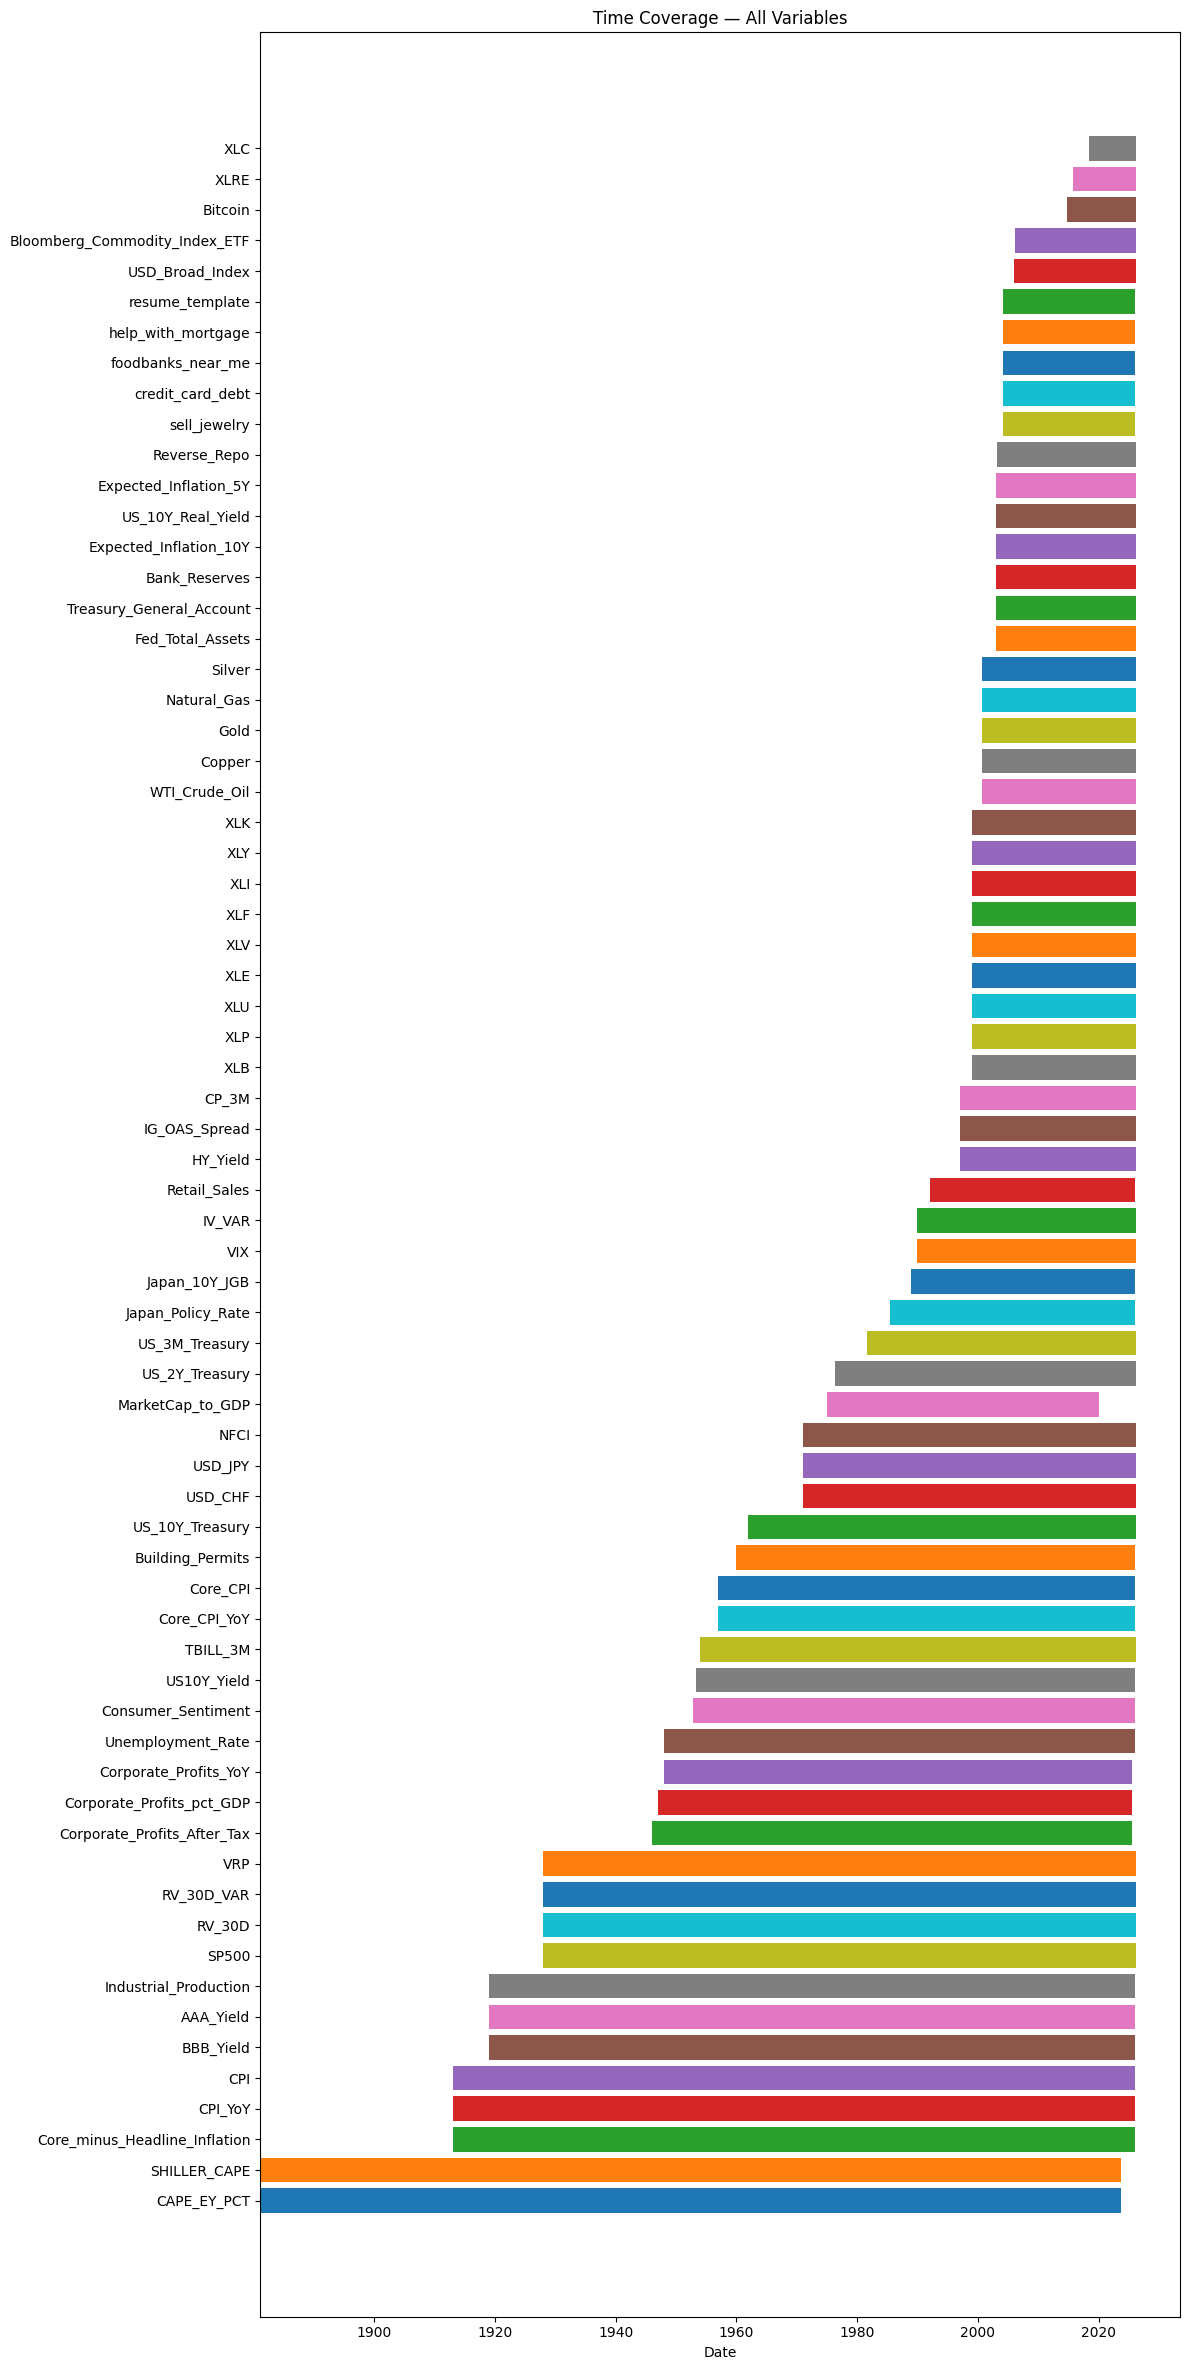

In [57]:
# =====================================================
# TIME COVERAGE MAP — ALL BLOCKS
# =====================================================

import matplotlib.pyplot as plt

# Combine all dictionaries
combined = {}
combined.update(yf_raw)
combined.update(fred_raw)
combined.update(trends_raw)
combined.update(url_raw)

coverage = []

for name, s in combined.items():
    if s.empty:
        continue
    
    coverage.append({
        "variable": name,
        "start": s.index.min(),
        "end": s.index.max()
    })

coverage_df = pd.DataFrame(coverage).sort_values("start")

plt.figure(figsize=(12, len(coverage_df) * 0.35))

for _, row in coverage_df.iterrows():
    plt.barh(
        row["variable"],
        (row["end"] - row["start"]).days,
        left=row["start"]
    )

plt.title("Time Coverage — All Variables")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

### Evaluation

In [58]:
# ==================================
# BLOCK 4 — INSPECT YFINANCE METADATA
# ==================================

yf_meta = []

for name, series in yf_raw.items():
    
    # Compute time differences
    time_diffs = series.index.to_series().diff().dropna()
    
    meta = {
        "variable": name,
        "start_date": series.index.min(),
        "end_date": series.index.max(),
        "n_obs": len(series),
        "n_missing": series.isna().sum(),
        "dtype": series.dtype,
        "avg_gap_days": time_diffs.dt.days.mean(),
        "most_common_gap_days": time_diffs.dt.days.mode()[0] if not time_diffs.empty else None
    }
    
    yf_meta.append(meta)

yf_meta_df = pd.DataFrame(yf_meta)

print("\nYFINANCE METADATA")
display(yf_meta_df)




YFINANCE METADATA


,variable,start_date,end_date,n_obs,n_missing,dtype,avg_gap_days,most_common_gap_days
0,SP500,1927-12-30,2026-03-27,24676,0,float64,1.454184,1
1,VIX,1990-01-02,2026-03-27,9126,0,float64,1.450192,1
2,RV_30D,1927-12-30,2026-03-27,24676,30,float64,1.454184,1
3,IV_VAR,1990-01-02,2026-03-27,9126,0,float64,1.450192,1
4,RV_30D_VAR,1927-12-30,2026-03-27,24676,30,float64,1.454184,1
5,VRP,1927-12-30,2026-03-27,24676,15550,float64,1.454184,1
6,XLK,1998-12-22,2026-03-27,6857,0,float64,1.452305,1
7,XLY,1998-12-22,2026-03-27,6857,0,float64,1.452305,1
8,XLI,1998-12-22,2026-03-27,6857,0,float64,1.452305,1
9,XLF,1998-12-22,2026-03-27,6857,0,float64,1.452305,1


In [59]:
# ===============================
# BLOCK 5 — INSPECT FRED METADATA
# ===============================

fred_meta = []

for name, series in fred_raw.items():
    
    # Compute time differences
    time_diffs = series.index.to_series().diff().dropna()
    
    meta = {
        "variable": name,
        "start_date": series.index.min(),
        "end_date": series.index.max(),
        "n_obs": len(series),
        "n_missing": series.isna().sum(),
        "dtype": series.dtype,
        "avg_gap_days": time_diffs.dt.days.mean(),
        "most_common_gap_days": time_diffs.dt.days.mode()[0] if not time_diffs.empty else None
    }
    
    fred_meta.append(meta)

fred_meta_df = pd.DataFrame(fred_meta)

print("\nFRED METADATA")
display(fred_meta_df)



FRED METADATA


,variable,start_date,end_date,n_obs,n_missing,dtype,avg_gap_days,most_common_gap_days
0,USD_Broad_Index,2006-01-02,2026-03-20,5275,208,float64,1.399697,1
1,USD_JPY,1971-01-04,2026-03-20,14405,566,float64,1.399889,1
2,USD_CHF,1971-01-04,2026-03-20,14405,560,float64,1.399889,1
3,Japan_Policy_Rate,1985-07-01,2026-02-01,488,0,float64,30.441478,31
4,Japan_10Y_JGB,1989-01-01,2026-02-01,446,0,float64,30.438202,31
5,Industrial_Production,1919-01-01,2026-02-01,1286,0,float64,30.438132,31
6,Unemployment_Rate,1948-01-01,2026-02-01,938,1,float64,30.438634,31
7,MarketCap_to_GDP,1975-01-01,2020-01-01,46,0,float64,365.244444,365
8,Consumer_Sentiment,1952-11-01,2026-02-01,880,210,float64,30.437998,31
9,Building_Permits,1960-01-01,2026-01-01,793,0,float64,30.438131,31


## Standarizing Vars

In [60]:
# =====================================================
# UNIFIED RAW DICT
# =====================================================

raw_all = {}
raw_all.update(yf_raw)
raw_all.update(fred_raw)
raw_all.update(trends_raw)
raw_all.update(url_raw)

In [61]:
# =====================================================
# WEEKDAY COUNTS (CLEAN)
# =====================================================

vars_to_check = [
    "NFCI",
    "Fed_Total_Assets",
    "Treasury_General_Account",
    "Bank_Reserves"
]

for k in vars_to_check:
    s = raw_all[k].dropna()
    weekday_counts = s.index.to_series().dt.day_name().value_counts()
    print(f"\n{k}")
    print(weekday_counts)


NFCI
Friday    2881
Name: count, dtype: int64

Fed_Total_Assets
Wednesday    1215
Name: count, dtype: int64

Treasury_General_Account
Wednesday    1215
Name: count, dtype: int64

Bank_Reserves
Wednesday    1215
Name: count, dtype: int64


### All vars to weekly 

In [62]:
# =====================================================
# WEEKLY GRID (CONFIG)
# =====================================================

beg_date = pd.Timestamp("2004-03-31")
end_date = pd.Timestamp("2025-12-31")

anchor_weekday = "FRI"          # "MON","TUE","WED","THU","FRI","SAT","SUN"
start_on_next_anchor = True

# --- Filters (drop variables that don't meet coverage / frequency requirements) ---
min_start_date = pd.Timestamp("2004-03-31")
min_end_date = pd.Timestamp("2025-12-31")
max_gap_days = 100

# --- Frequency classifiers (used to decide HOW to resample/align each kept series) ---
daily_max_gap = 3
weekly_max_gap = 10
monthly_max_gap = 45
quarterly_max_gap = 100


# =====================================================
# HELPERS
# =====================================================

weekday_map = {"MON": 0, "TUE": 1, "WED": 2, "THU": 3, "FRI": 4, "SAT": 5, "SUN": 6}
weekly_rule = f"W-{anchor_weekday}"

def dominant_gap_days(s):
    s = s.dropna()
    if len(s.index) < 3:
        return None
    diffs = s.index.to_series().diff().dropna()
    return None if diffs.empty else float(diffs.dt.days.mode().iloc[0])

def next_weekday_after(dt, weekday_str):
    wd_target = weekday_map[weekday_str]
    d = dt.normalize()
    delta = (wd_target - d.weekday()) % 7
    if delta == 0:
        delta = 7
    return d + pd.Timedelta(days=delta)

start_anchor = next_weekday_after(beg_date, anchor_weekday) if start_on_next_anchor else beg_date
weekly_index = pd.date_range(start=start_anchor, end=end_date, freq=weekly_rule)


# =====================================================
# FILTER + ALIGN LOOP (raw_all already exists)
# =====================================================

weekly_df = pd.DataFrame(index=weekly_index)

dropped = []  # <- collect dropped vars + reason

for key, s in raw_all.items():

    s = s.sort_index().dropna()
    if s.empty:
        dropped.append((key, "empty"))
        continue

    s_start, s_end = s.index.min(), s.index.max()

    # filter by coverage
    if s_start > min_start_date:
        dropped.append((key, f"start_after_min_start ({s_start.date()})"))
        continue
    if s_end < min_end_date:
        dropped.append((key, f"end_before_min_end ({s_end.date()})"))
        continue

    # filter by dominant gap
    gap = dominant_gap_days(s)
    if gap is None:
        dropped.append((key, "gap_none (too_few_obs)"))
        continue
    if gap > max_gap_days:
        dropped.append((key, f"gap_too_large ({gap:.0f}d)"))
        continue

    # align to weekly
    if gap <= daily_max_gap:
        s_week = s.resample(weekly_rule).last()
    elif gap <= weekly_max_gap:
        s_week = s.reindex(weekly_index, method="ffill")
    elif gap <= monthly_max_gap or gap <= quarterly_max_gap:
        s_week = s.resample(weekly_rule).ffill()
    else:
        dropped.append((key, f"unclassified_gap ({gap:.0f}d)"))
        continue

    weekly_df[key] = s_week.reindex(weekly_index)


# =====================================================
# PRINT DROPPED VARIABLES
# =====================================================

print(f"\nDropped variables: {len(dropped)}")
for k, reason in dropped:
    print(f"- {k}: {reason}")


Dropped variables: 11
- XLC: start_after_min_start (2018-06-19)
- XLRE: start_after_min_start (2015-10-08)
- Bitcoin: start_after_min_start (2014-09-17)
- Bloomberg_Commodity_Index_ETF: start_after_min_start (2006-02-06)
- USD_Broad_Index: start_after_min_start (2006-01-02)
- MarketCap_to_GDP: end_before_min_end (2020-01-01)
- Corporate_Profits_After_Tax: end_before_min_end (2025-07-01)
- Corporate_Profits_YoY: end_before_min_end (2025-07-01)
- Corporate_Profits_pct_GDP: end_before_min_end (2025-07-01)
- SHILLER_CAPE: end_before_min_end (2023-09-30)
- CAPE_EY_PCT: end_before_min_end (2023-09-30)


#### Chequeo

In [63]:
# =====================================================
# SUMMARY
# =====================================================

print("weekly_df shape (rows, cols):", weekly_df.shape)
print("date range:", weekly_df.index.min(), "->", weekly_df.index.max())

total_cells = weekly_df.shape[0] * weekly_df.shape[1]
total_nans = int(weekly_df.isna().sum().sum())
print("total NaNs:", total_nans, f"({total_nans/total_cells:.2%} of all cells)")

nans_by_col = weekly_df.isna().sum().sort_values(ascending=False)
print("\nTop 10 columns by NaNs:")
print(nans_by_col.head(10))

print("\nNaN rows (rows with any missing):", int(weekly_df.isna().any(axis=1).sum()))

weekly_df shape (rows, cols): (1135, 57)
date range: 2004-04-02 00:00:00 -> 2025-12-26 00:00:00
total NaNs: 633 (0.98% of all cells)

Top 10 columns by NaNs:
Reverse_Repo    460
CP_3M           173
RV_30D            0
VIX               0
RV_30D_VAR        0
VRP               0
XLK               0
IV_VAR            0
SP500             0
XLF               0
dtype: int64

NaN rows (rows with any missing): 557


In [64]:
# A) Ver que el índice es semanal y cae en el día ancla
print("Index freq guess:", pd.infer_freq(weekly_df.index))
print("Weekday counts:")
print(weekly_df.index.to_series().dt.day_name().value_counts())

# B) Chequeo de gaps en el índice (debería ser ~7 días)
gaps = weekly_df.index.to_series().diff().dt.days.dropna()
print("\nIndex gap days counts:")
print(gaps.value_counts().sort_index())

# C) Spot check: comparar una serie original vs la semanal
k = "SP500"  # cambia por la que quieras
check = pd.concat(
    [raw_all[k].rename("raw"), weekly_df[k].rename("weekly")],
    axis=1
)
display(check.dropna().head(15))

Index freq guess: W-FRI
Weekday counts:
Friday    1135
Name: count, dtype: int64

Index gap days counts:
7.0    1134
Name: count, dtype: int64


,raw,weekly
2004-04-02,1141.810059,1141.810059
2004-04-16,1134.609985,1134.609985
2004-04-23,1140.599976,1140.599976
2004-04-30,1107.300049,1107.300049
2004-05-07,1098.699951,1098.699951
2004-05-14,1095.699951,1095.699951
2004-05-21,1093.560059,1093.560059
2004-05-28,1120.680054,1120.680054
2004-06-04,1122.500000,1122.500000
2004-06-18,1135.020020,1135.020020


In [65]:
# =====================================================
# SPOT CHECK (WEEKLY RAW vs WEEKLY)
# =====================================================

k = "Fed_Total_Assets"

print("\nRAW (first 10 after beg_date)")
print(raw_all[k].loc[beg_date:].dropna().head(10))

print("\nWEEKLY (first 10 after beg_date)")
print(weekly_df[k].loc[beg_date:].dropna().head(10))


RAW (first 10 after beg_date)
2004-03-31    760725.0
2004-04-07    754083.0
2004-04-14    763734.0
2004-04-21    757984.0
2004-04-28    772927.0
2004-05-05    758838.0
2004-05-12    764835.0
2004-05-19    756874.0
2004-05-26    771108.0
2004-06-02    764090.0
Name: Fed_Total_Assets, dtype: float64

WEEKLY (first 10 after beg_date)
2004-04-02    760725.0
2004-04-09    754083.0
2004-04-16    763734.0
2004-04-23    757984.0
2004-04-30    772927.0
2004-05-07    758838.0
2004-05-14    764835.0
2004-05-21    756874.0
2004-05-28    771108.0
2004-06-04    764090.0
Freq: W-FRI, Name: Fed_Total_Assets, dtype: float64


In [66]:
# =====================================================
# SPOT CHECK (MONTHLY RAW vs WEEKLY)
# =====================================================

k = "Core_CPI"

# RAW: first 3 months after beg_date
print("\nRAW (first 3 after beg_date)")
print(raw_all[k].loc[beg_date:].dropna().head(3))

# WEEKLY: first 12 weeks after beg_date
print("\nWEEKLY (first 12 after beg_date)")
print(weekly_df[k].loc[beg_date:].dropna().head(12))


RAW (first 3 after beg_date)
2004-04-01    195.9
2004-05-01    196.2
2004-06-01    196.6
Name: Core_CPI, dtype: float64

WEEKLY (first 12 after beg_date)
2004-04-02    195.9
2004-04-09    195.9
2004-04-16    195.9
2004-04-23    195.9
2004-04-30    195.9
2004-05-07    196.2
2004-05-14    196.2
2004-05-21    196.2
2004-05-28    196.2
2004-06-04    196.6
2004-06-11    196.6
2004-06-18    196.6
Freq: W-FRI, Name: Core_CPI, dtype: float64


#### Nans

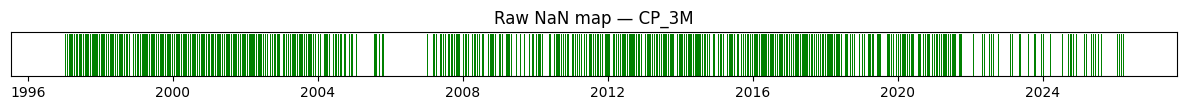

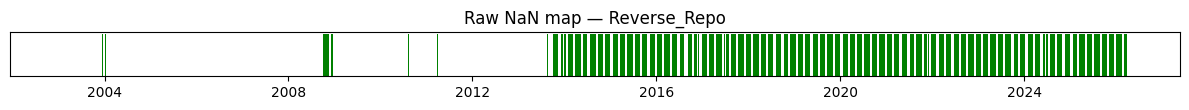

In [67]:
# =====================================================
# NaN MAP ON RAW SERIES (NO WEEKLY RESAMPLING)
# =====================================================

for k in ["CP_3M", "Reverse_Repo"]:
    s = raw_all[k].sort_index()  # keep raw frequency
    mask_nan = s.isna().to_numpy()
    colors = np.where(mask_nan, "red", "green")

    plt.figure(figsize=(12, 1.2))
    plt.bar(s.index, np.ones(len(s)), color=colors, width=1)

    plt.title(f"Raw NaN map — {k}")
    plt.yticks([])
    plt.tight_layout()
    plt.show()

Columns with NaNs: ['CP_3M', 'Reverse_Repo']


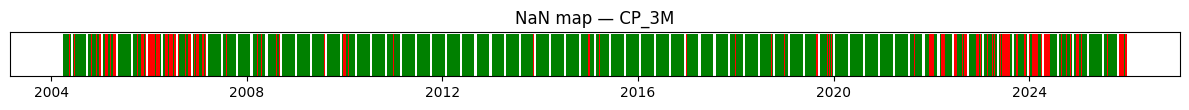

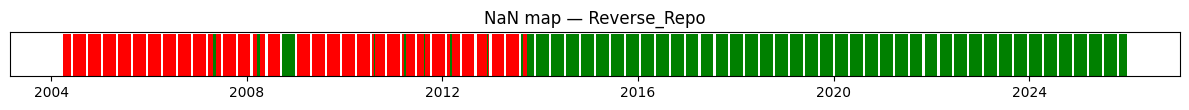

In [68]:
# =====================================================
# NAN MAP (GREEN = OK, RED = NaN) — auto for the 2 columns with NaNs
# =====================================================

nan_cols = [c for c in weekly_df.columns if weekly_df[c].isna().any()]

print("Columns with NaNs:", nan_cols)

for c in nan_cols:
    mask_nan = weekly_df[c].isna().to_numpy()          # True where NaN
    colors = np.where(mask_nan, "red", "green")        # red=NaN, green=ok

    plt.figure(figsize=(12, 1.2))
    plt.bar(weekly_df.index, np.ones(len(weekly_df)), color=colors, width=6)

    plt.title(f"NaN map — {c}")
    plt.yticks([])
    plt.tight_layout()
    plt.show()

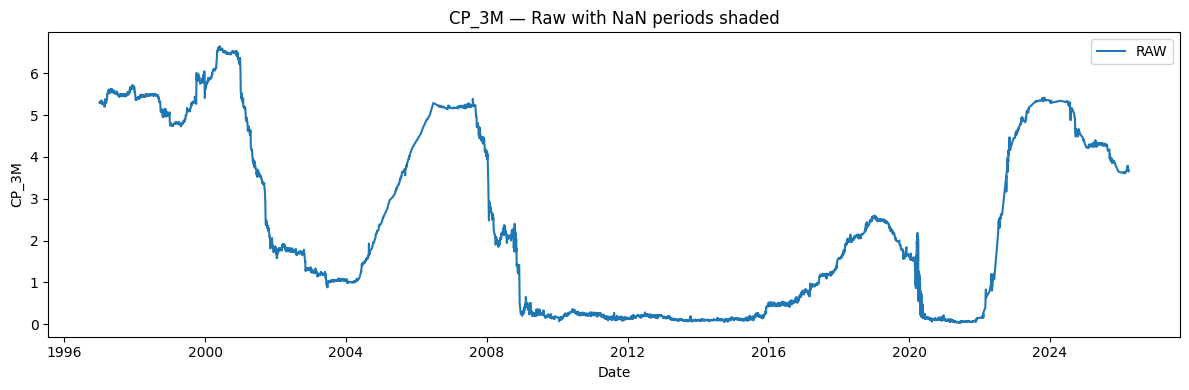

In [69]:
# =====================================================
# CP_3M — LINE PLOT + SHADE NaN PERIODS
# =====================================================

k = "CP_3M"
s = raw_all[k].sort_index()

# mask for NaNs
nan_mask = s.isna()

# find contiguous NaN blocks
blocks = []
in_block = False
start = None

for dt, is_nan in nan_mask.items():
    if is_nan and not in_block:
        in_block = True
        start = dt
    elif (not is_nan) and in_block:
        end = dt
        blocks.append((start, end))
        in_block = False

# if series ends in NaNs
if in_block:
    blocks.append((start, s.index[-1]))

plt.figure(figsize=(12, 4))

# plot the line (NaNs won't draw)
plt.plot(s.index, s.values, label="RAW")

# shade NaN blocks
ax = plt.gca()
for a, b in blocks:
    ax.axvspan(a, b, alpha=0.25)  # shaded NaN region

plt.title(f"{k} — Raw with NaN periods shaded")
plt.xlabel("Date")
plt.ylabel(k)
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
# =====================================================
# CLEANUP
# =====================================================

# 1) Fill CP_3M weekly gaps (carry last value forward until next update)
weekly_df["CP_3M"] = weekly_df["CP_3M"].ffill()

# 2) Drop Reverse_Repo column
weekly_df = weekly_df.drop(columns=["Reverse_Repo"], errors="ignore")

In [71]:
# =====================================================
# SUMMARY
# =====================================================

print("weekly_df shape (rows, cols):", weekly_df.shape)
print("date range:", weekly_df.index.min(), "->", weekly_df.index.max())

total_cells = weekly_df.shape[0] * weekly_df.shape[1]
total_nans = int(weekly_df.isna().sum().sum())
print("total NaNs:", total_nans, f"({total_nans/total_cells:.2%} of all cells)")

nans_by_col = weekly_df.isna().sum().sort_values(ascending=False)
print("\nTop 10 columns by NaNs:")
print(nans_by_col.head(10))

print("\nNaN rows (rows with any missing):", int(weekly_df.isna().any(axis=1).sum()))

weekly_df shape (rows, cols): (1135, 56)
date range: 2004-04-02 00:00:00 -> 2025-12-26 00:00:00
total NaNs: 0 (0.00% of all cells)

Top 10 columns by NaNs:
SP500         0
VIX           0
RV_30D        0
IV_VAR        0
RV_30D_VAR    0
VRP           0
XLK           0
XLY           0
XLI           0
XLF           0
dtype: int64

NaN rows (rows with any missing): 0


## Variables derivadas

In [72]:
# 1) Quick scan
print("N cols:", len(weekly_df.columns))
# print(sorted(weekly_df.columns))

# 2) Helper: check required inputs for your derived blocks
required_sets = {
    # Sector rotation ETFs
    "Sector_Rotation (ETFs)": ["XLK","XLY","XLI","XLF","XLB","XLE","XLC","XLP","XLU","XLV","XLRE"],

    # Credit spreads inputs
    "BBB_AAA_Credit_Spread": ["BBB_Yield","AAA_Yield"],
    "High_Yield_Spread": ["HY_Yield","US10Y_Yield"],
    "Short_Term_Credit_Spread": ["CP_3M","TBILL_3M"],
    "Long_Term_Credit_Spread": ["BBB_Yield","US10Y_Yield"],

    # Term structure: check the INPUTS needed to build ST and LT
    "Credit_Spread_Term_Struct": ["CP_3M","TBILL_3M","BBB_Yield","US10Y_Yield"],

    # Net liquidity inputs
    "Net_Liquidity": ["Fed_Total_Assets","Treasury_General_Account","Reverse_Repo"],

    # Yield curve
    "Spread_10Y_2Y": ["US_10Y_Treasury","US_2Y_Treasury"],
    "Spread_10Y_3M": ["US_10Y_Treasury","US_3M_Treasury"],
}

# 3) Check directly against weekly_df columns:
for k, req in required_sets.items():
    missing = [c for c in req if c not in weekly_df.columns]
    if missing:
        print(f"{k}: MISSING -> {missing}")
    else:
        print(f"{k}: OK")

N cols: 56
Sector_Rotation (ETFs): MISSING -> ['XLC', 'XLRE']
BBB_AAA_Credit_Spread: OK
High_Yield_Spread: OK
Short_Term_Credit_Spread: OK
Long_Term_Credit_Spread: OK
Credit_Spread_Term_Struct: OK
Net_Liquidity: MISSING -> ['Reverse_Repo']
Spread_10Y_2Y: OK
Spread_10Y_3M: OK


In [73]:
df_n = weekly_df.copy()

# =====================================================
# Sector Rotation (Cyclicals - Defensives), using available ETFs
# =====================================================
CYCLICALS = ["XLK", "XLY", "XLI", "XLF", "XLB", "XLE"]   # XLC missing
DEFENSIVES = ["XLP", "XLU", "XLV"]                    # XLRE missing

cyc_cols = [c for c in CYCLICALS if c in df_n.columns]
def_cols = [c for c in DEFENSIVES if c in df_n.columns]

if len(cyc_cols) >= 3 and len(def_cols) >= 3:
    prices = df_n[cyc_cols + def_cols].astype(float)
    rets = np.log(prices).diff(1)  # weekly log returns
    df_n["Sector_Rotation"] = rets[cyc_cols].mean(axis=1) - rets[def_cols].mean(axis=1)
    print(f"Sector_Rotation created. cyc={cyc_cols}, def={def_cols}")
else:
    print(f"Sector_Rotation skipped. cyc={cyc_cols}, def={def_cols}")

# =====================================================
# Credit spreads
# =====================================================
df_n["BBB_AAA_Credit_Spread"] = df_n["BBB_Yield"] - df_n["AAA_Yield"]
df_n["High_Yield_Spread"] = df_n["HY_Yield"] - df_n["US10Y_Yield"]
df_n["Short_Term_Credit_Spread"] = df_n["CP_3M"] - df_n["TBILL_3M"]
df_n["Long_Term_Credit_Spread"] = df_n["BBB_Yield"] - df_n["US10Y_Yield"]
df_n["Credit_Spread_Term_Struct"] = df_n["Short_Term_Credit_Spread"] - df_n["Long_Term_Credit_Spread"]

# =====================================================
# Yield curve spreads (Treasury series)
# =====================================================
df_n["Spread_10Y_2Y"] = df_n["US_10Y_Treasury"] - df_n["US_2Y_Treasury"]
df_n["Spread_10Y_3M"] = df_n["US_10Y_Treasury"] - df_n["US_3M_Treasury"]

# =====================================================
# Net Liquidity
# =====================================================

print("\nNew columns added:")
added = ["Sector_Rotation","BBB_AAA_Credit_Spread","High_Yield_Spread",
         "Short_Term_Credit_Spread","Long_Term_Credit_Spread","Credit_Spread_Term_Struct",
         "Spread_10Y_2Y","Spread_10Y_3M","Net_Liquidity_NoRRP"]
print([c for c in added if c in df_n.columns])

Sector_Rotation created. cyc=['XLK', 'XLY', 'XLI', 'XLF', 'XLB', 'XLE'], def=['XLP', 'XLU', 'XLV']

New columns added:
['Sector_Rotation', 'BBB_AAA_Credit_Spread', 'High_Yield_Spread', 'Short_Term_Credit_Spread', 'Long_Term_Credit_Spread', 'Credit_Spread_Term_Struct', 'Spread_10Y_2Y', 'Spread_10Y_3M']


In [74]:
# Drop the RAW INPUT columns used to create the derived variables
to_drop_inputs = [
    # Sector rotation ETF inputs
    "XLK","XLY","XLI","XLF","XLB","XLE","XLC",
    "XLP","XLU","XLV","XLRE",

    # Credit spread inputs
    "BBB_Yield","AAA_Yield","HY_Yield","US10Y_Yield",
    "CP_3M","TBILL_3M",

    # Yield curve inputs
    # "US_10Y_Treasury","US_2Y_Treasury","US_3M_Treasury",

    # Net liquidity inputs (proxy/full)
    #"Fed_Total_Assets","Treasury_General_Account"
]

df_n = df_n.drop(columns=[c for c in to_drop_inputs if c in df_n.columns])

print("Dropped inputs. Remaining columns:", len(df_n.columns))

Dropped inputs. Remaining columns: 49


### Download csv

In [75]:
# save
df_n.to_csv("prepared_data/weekly_df.csv", index=True)

print("Saved to prepared_data/weekly_df.csv")

Saved to prepared_data/weekly_df.csv
